In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
df=pd.read_csv("customer_support_text_classification.csv")
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [11]:
print("Total Records:", len(df))
print(f"Target classes/labels {df['sentiment_label'].unique()}")
print("Following are sample text records")
df['customer_message'].head()

Total Records: 1500
Target classes/labels ['neutral' 'positive' 'negative']
Following are sample text records


0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

In [12]:
#Average text length
df["text_length"] = df['customer_message'].apply(lambda x: len(str(x).split()))
avg_length = df["text_length"].mean()
print(f"Average length of the text message: {avg_length}")

Average length of the text message: 12.722666666666667


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


Text(0, 0.5, 'Count')

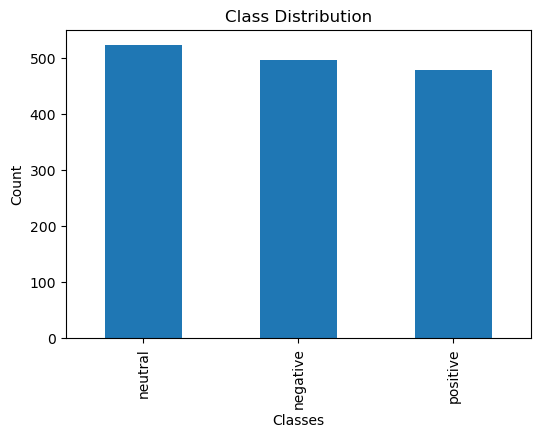

In [13]:
#Class distribution
class_distribution = df['sentiment_label'].value_counts()
print(class_distribution)
plt.figure(figsize=(6,4))
class_distribution.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

In [15]:
print("sentence that has maximum number of words")
print(df[df['word_count']==df['word_count'].max()])


sentence that has maximum number of words
    ticket_id channel                                   customer_message  \
892  TKT00893   phone  I am very unhappy because my order has not wor...   

    sentiment_label  word_count  urgent_flag  
892        negative          26            1  


<Axes: xlabel='urgent_flag'>

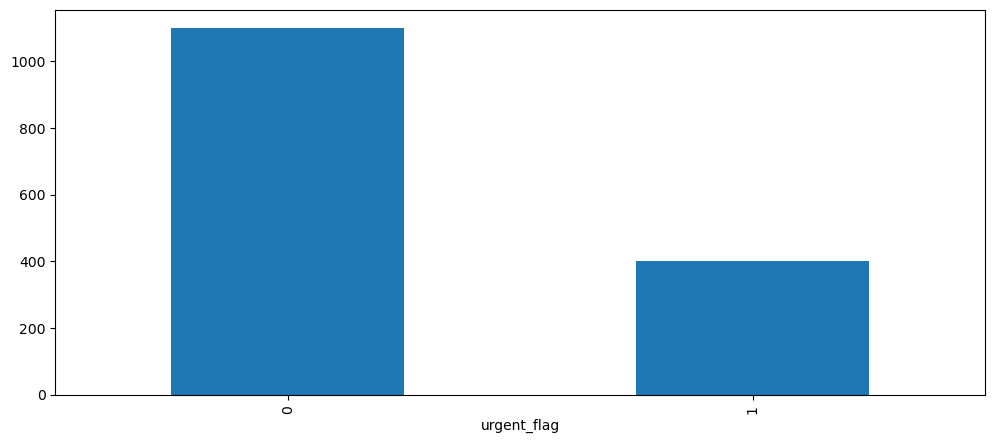

In [19]:
plt.figure(figsize=(12,5))
urgent_flag_count=df['urgent_flag'].value_counts()
urgent_flag_count.plot(kind='bar')

sentiment_label  urgent_flag
negative         1              281
                 0              216
neutral          0              405
                 1              119
positive         0              479
Name: count, dtype: int64


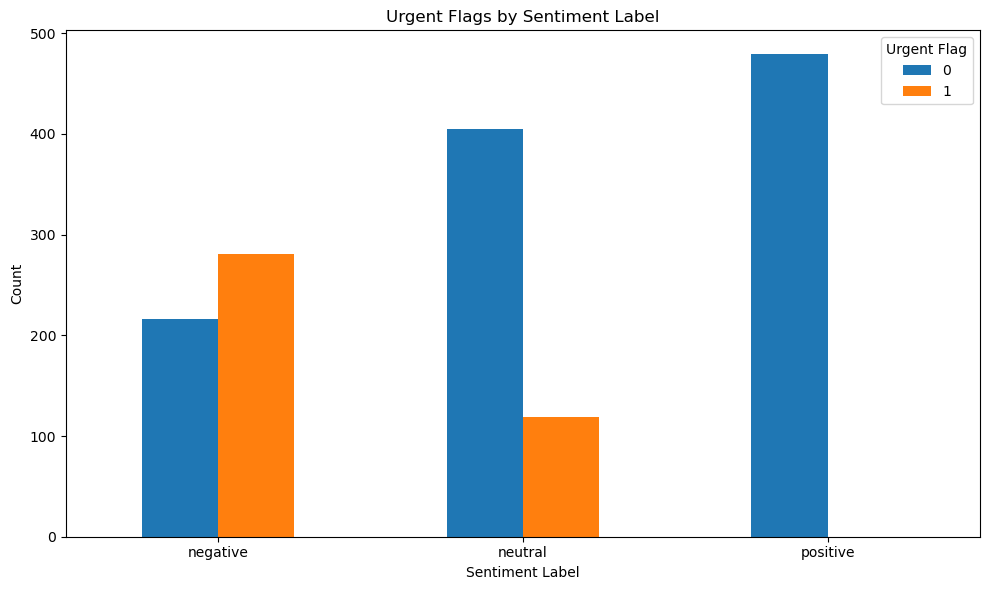

In [24]:
grouped_by_label=df.groupby("sentiment_label")
flag_label_wise=grouped_by_label['urgent_flag'].value_counts()
print(flag_label_wise)
flag_label_wise = pd.crosstab(df['sentiment_label'], df['urgent_flag'])
flag_label_wise.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Urgent Flags by Sentiment Label')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.legend(title='Urgent Flag')
plt.tight_layout()
plt.savefig('sentiment_urgent_plot.png')


channel  urgent_flag
app      0              192
         1               82
chat     0              211
         1               79
email    0              255
         1               71
phone    0              219
         1               77
social   0              223
         1               91
Name: count, dtype: int64


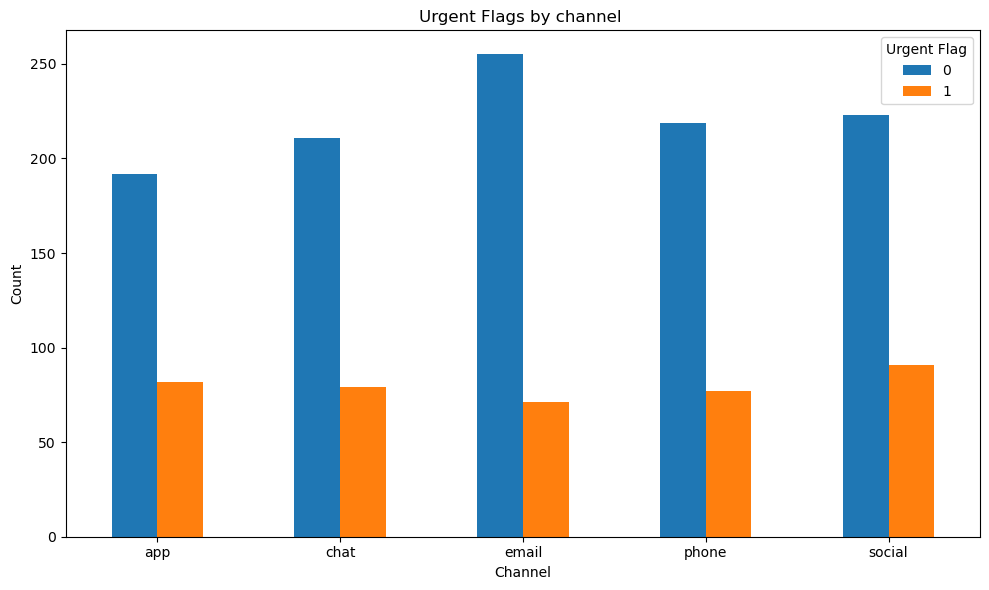

In [26]:
grouped_by_channel=df.groupby("channel")
flag_channel_wise=grouped_by_channel['urgent_flag'].value_counts()
print(flag_channel_wise)
flag_channel_wise = pd.crosstab(df['channel'], df['urgent_flag'])
flag_channel_wise.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Urgent Flags by channel ')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.legend(title='Urgent Flag')
plt.tight_layout()
plt.savefig('Channel_urgent_plot.png')

In [30]:
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
import re
from sklearn.base import BaseEstimator, TransformerMixin
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
negation_words = {
               "not", "no", "nor", "never",
                "don't", "didn't", "won't",
                 "can't", "isn't", "wasn't",
               "aren't", "couldn't", "shouldn't"}
stop_words = stop_words - negation_words

class TextPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        cleaned_text = []

        for text in X:

            # lowercase
            text = text.lower()

            # removing special characters
            text = re.sub(r'[^a-zA-Z\s]', '', text)

            # tokenizing
            tokens = word_tokenize(text)

            # removing stopwords
           

            tokens = [word for word in tokens if word not in stop_words]

            cleaned_text.append(" ".join(tokens))

        return cleaned_text

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2),max_features=500,min_df=2)),
    ("classifier", LogisticRegression())
])

In [7]:
X = df["customer_message"]

y = df["sentiment_label"]

pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [10]:
new_text = [
    "very nice service."
]

prediction = pipeline.predict(new_text)

print(prediction)

['positive']


In [11]:
probabilities = pipeline.predict_proba(new_text)

print(probabilities)

[[0.28975515 0.13399552 0.57624933]]


In [13]:
import joblib

joblib.dump(
    pipeline,
    "sentiment_pipeline.pkl"
)

['sentiment_pipeline.pkl']